# E-Commerce Sales Prediction model

This business is working towards optimizing inventory and supply chain decisions by identifying time of high demand. However, there is
no structured system that can forecast sales trend across time. This creates problems in restocking, leading stockout during peak demands.
This project aims at analyzing the sales data to identify patterns and trends, and then build a predictive model to forecast future sales.
The objectives of this project are: To perform exploratory Data Analysis to identify sales trend and also the relationship between variables in this dataset, To identify factors that influence sales performance, To build and evaluate a machine learning model for forecasting future sales. 
The insights gained from this analysis will help the business make informed decisions about inventory management, marketing strategies and overall business planning.

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler







Data Loading and Cleaning

In [2]:
# Load the dataset
df=pd.read_csv('Sales_Data_2024_2025.csv')
df.info()
df.describe()
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())
# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Detecting Outliers using IQR
print("\nShape before outlier removal:", df.shape)
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
valid_mask = pd.Series(True, index=df.index)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nOutliers in {col}:")
    print(f"\n{outliers[[col]]}")
# filter the dataframe using the mask
valid_mask = valid_mask & (df[col]>= lower_bound) & (df[col]<= upper_bound)
df_cleaned=df[valid_mask]
print("\nShape after outlier removal:", df.shape)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB

Missing values in each column:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             

The dataset of 5000 rows and 14 columns was checked for missing values and duplicates and no issues were found.Outliers in the numerical columns were detected using the IQR method, 
the shape of the dataset before and after outlier removal was printed.Since the shape is the same , it indicates that no outliers were removed from the dataset. 
This suggests that the dataset is clean and ready for further analysis and modeling without any outlier-related issues.

# Feature Engineering

In [3]:
# Date Handling
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month 
df['Day'] = df['Order Date'].dt.day
df.shape

(5000, 17)

From the  Order Date variable, we obtained the year, month and day features. This explains the increase
of columns from 14 to 17

# Exploratory Data Analysis
Here, we will perform multivariate analysis, skewness, kurtosis, and correlation analysis.
Additionally, we will check the trend of sales over time and their distribution over different categories and regions

# Correlation analysis

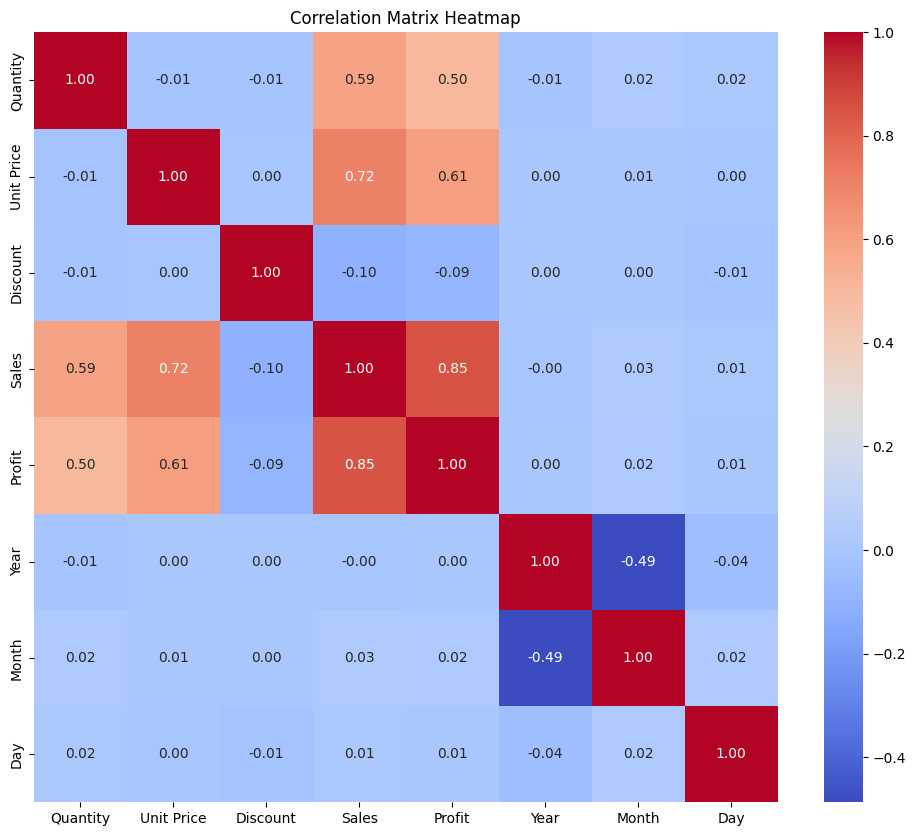

            Quantity  Unit Price  Discount     Sales    Profit      Year  \
Quantity    1.000000   -0.010982 -0.007955  0.588705  0.502701 -0.009208   
Unit Price -0.010982    1.000000  0.000475  0.715123  0.606293  0.003286   
Discount   -0.007955    0.000475  1.000000 -0.101611 -0.088516  0.002388   
Sales       0.588705    0.715123 -0.101611  1.000000  0.848792 -0.003165   
Profit      0.502701    0.606293 -0.088516  0.848792  1.000000  0.003157   
Year       -0.009208    0.003286  0.002388 -0.003165  0.003157  1.000000   
Month       0.020833    0.010850  0.001170  0.026437  0.023636 -0.487371   
Day         0.015853    0.000161 -0.012187  0.014422  0.012217 -0.041253   

               Month       Day  
Quantity    0.020833  0.015853  
Unit Price  0.010850  0.000161  
Discount    0.001170 -0.012187  
Sales       0.026437  0.014422  
Profit      0.023636  0.012217  
Year       -0.487371 -0.041253  
Month       1.000000  0.018792  
Day         0.018792  1.000000  


In [4]:
#Correlation analysis between the numeric features and sales
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in ['Order ID', 'Order Id']  ]
correlation_matrix = df[numeric_cols].corr()
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Print the correlation values
print(correlation_matrix)


We can see that there is a strong positive relationship between sales and profit and a moderate
relationship between sales and quantity. Additionally , there is a weak negative correlation between
sales and order Id.

Now let's encode the non numerical features and check the overall correlation again

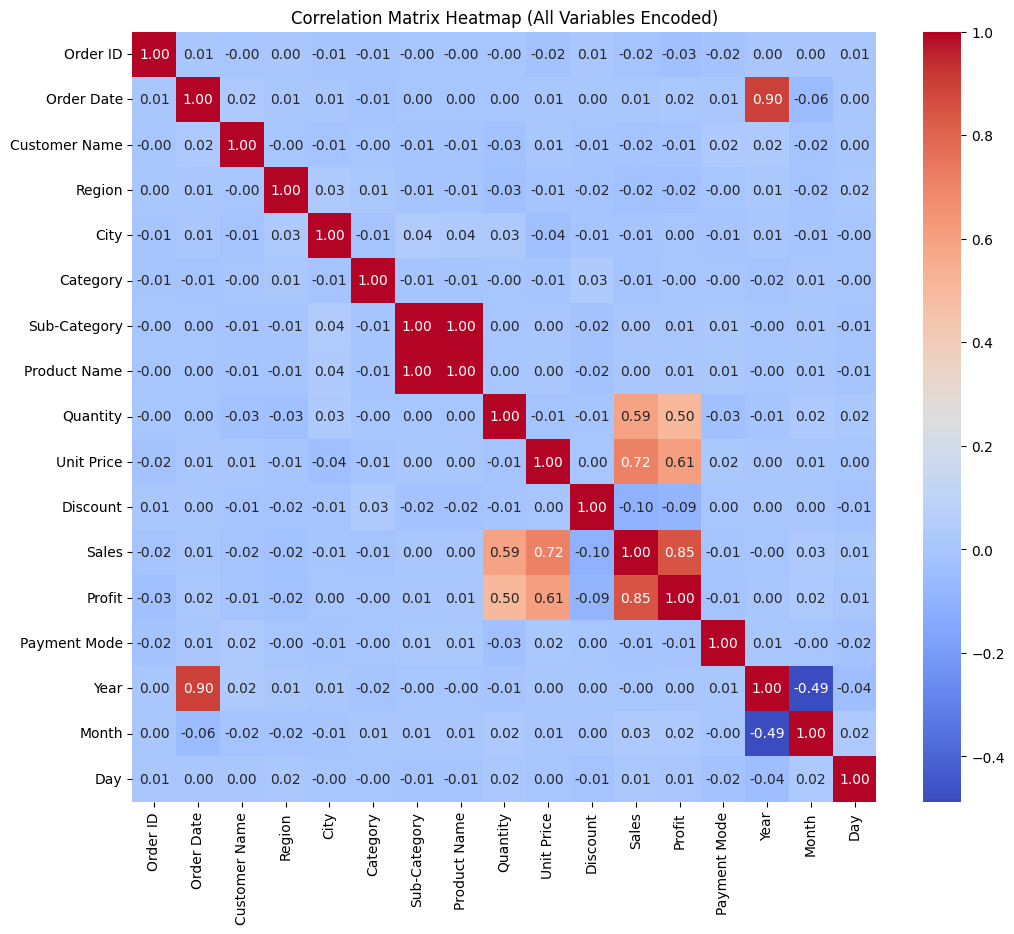

               Order ID  Order Date  Customer Name    Region      City  \
Order ID       1.000000    0.007415      -0.001163  0.001479 -0.007729   
Order Date     0.007415    1.000000       0.020196  0.008766  0.005477   
Customer Name -0.001163    0.020196       1.000000 -0.004403 -0.012064   
Region         0.001479    0.008766      -0.004403  1.000000  0.029455   
City          -0.007729    0.005477      -0.012064  0.029455  1.000000   
Category      -0.008964   -0.012992      -0.003408  0.012654 -0.014535   
Sub-Category  -0.003487    0.000337      -0.010851 -0.007709  0.035625   
Product Name  -0.003929    0.000625      -0.010788 -0.007409  0.035443   
Quantity      -0.002673    0.000522      -0.025415 -0.031912  0.025399   
Unit Price    -0.017612    0.009190       0.005909 -0.008209 -0.036581   
Discount       0.010596    0.002794      -0.009606 -0.016536 -0.005984   
Sales         -0.016595    0.010204      -0.015393 -0.023188 -0.006425   
Profit        -0.028416    0.015938   

In [5]:
# Encoding the non numerical features (Label Encoding)
df_encoded = df.copy()
label_encoder = LabelEncoder()  
for column in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Calculate the correlation matrix for the encoded dataframe
correlation_matrix_encoded = df_encoded.corr()

# Visualize the new correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap (All Variables Encoded)')
plt.show()

# Print the correlation values
print(correlation_matrix_encoded)


# Insights
From the correlation analysis, we can see that sales has a strong relationship with profit. That implies that increasing one feature leads to an increase of the other feature. 
Moreover, Sales have a strong positive correlation  the quantity sold and the unit price.

# Multivariate Analysis

In [6]:
# Multivariate analysis
display (df.groupby(['Category', 'Region'])['Sales'].sum().sort_values(ascending=False))

Category     Region
Kitchen      West      17323216.35
Home Decor   North     17286752.95
Furniture    West      16895925.05
Clothing     North     15930578.90
Home Decor   East      15589662.00
Books        North     15441895.30
Electronics  East      15165897.55
Furniture    North     15085776.75
Electronics  North     14439593.55
Groceries    North     14357007.65
Books        East      14173354.80
Beauty       North     13984910.85
Sports       North     13754083.95
Clothing     East      13684994.15
Toys         East      13539714.50
Kitchen      South     13399212.00
Clothing     South     13261557.80
Toys         South     13168919.85
Furniture    East      13090179.45
Toys         West      13002164.05
Sports       East      12964689.30
Books        South     12948754.30
Beauty       East      12790403.80
Kitchen      East      12724395.80
Sports       South     12687812.90
             West      12662811.10
Toys         North     12516568.05
Books        West      12368638.60


In [7]:
display (df.groupby(['Category', 'City'])['Sales'].sum().sort_values(ascending=False))

Category    City              
Kitchen     Goa                   5014747.95
Books       Lucknow               4695507.05
Clothing    Bangalore             4329827.95
Beauty      Guwahati              4271225.30
Kitchen     Chennai               4212727.05
                                     ...    
Clothing    Ahmedabad             1538676.75
Furniture   Thiruvananthapuram    1534306.00
Home Decor  Surat                 1485377.55
Beauty      Thiruvananthapuram    1297776.65
Home Decor  Hyderabad             1209691.75
Name: Sales, Length: 200, dtype: float64

In [8]:
display (df.groupby(['Payment Mode', 'Region'])['Sales'].sum().sort_values(ascending=False))

Payment Mode  Region
COD           North     31875487.85
Credit Card   East      30595538.50
Net Banking   North     29814580.20
Debit Card    East      28891423.00
Credit Card   North     28538077.10
Net Banking   West      28519375.65
Debit Card    North     28286333.20
COD           West      28083905.20
Net Banking   East      27663018.60
UPI           South     26303804.05
COD           South     25468819.90
Net Banking   South     25468541.60
UPI           West      25369539.15
              East      25208474.55
              North     25063767.75
Debit Card    West      24783681.15
Credit Card   West      24289472.20
COD           East      23453183.30
Debit Card    South     23384944.30
Credit Card   South     22604057.10
Name: Sales, dtype: float64

In [9]:
display (df.groupby(['Month', 'Region', 'City', 'Category','Quantity','Unit Price', 'Payment Mode'])['Sales'].sum().sort_values(ascending=False))

Month  Region  City         Category     Quantity  Unit Price  Payment Mode
2      West    Surat        Sports       5         79697       COD             398485.00
10     South   Coimbatore   Home Decor   5         78716       Net Banking     393580.00
5      North   Amritsar     Groceries    5         78382       Debit Card      391910.00
3      North   Lucknow      Electronics  5         76437       UPI             382185.00
7      South   Bangalore    Kitchen      5         76009       Debit Card      380045.00
                                                                                 ...    
4      East    Bhubaneswar  Furniture    1         426         Debit Card         362.10
8      South   Chennai      Toys         1         367         Debit Card         330.30
3      East    Patna        Books        1         317         Net Banking        269.45
8      West    Goa          Beauty       1         279         Net Banking        265.05
11     East    Patna        Furnit

From the analysis we discovered that during the month of February, in the West region, we had the highest sales 
in goods from Sports category. The specific city is Surat. This show that the demand of beauty products in Surat in February were high.
If the business had made more restocking and marketing efforts then they would probably have made more sales and profit.
Let us proceed to check the sales relationship with other variables using pairplot and scatter plot.

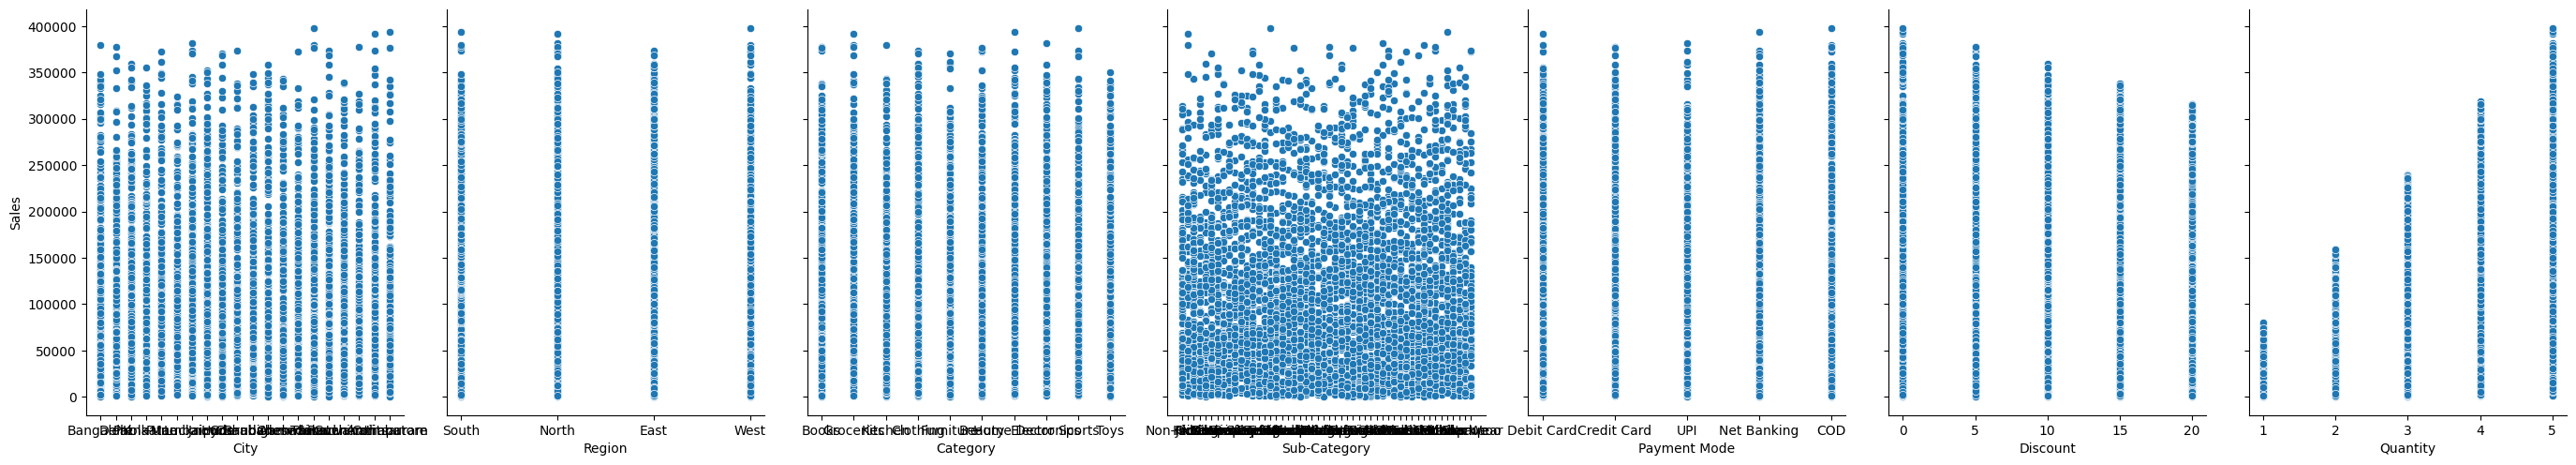

In [10]:
# Check linearity between sales and city, Region, Category, Sub-Category, Payment Mode
sns.pairplot(df, x_vars=['City', 'Region', 'Category', 'Sub-Category', 'Payment Mode', 'Discount', 'Quantity'], y_vars='Sales', height=5, aspect=0.8)
plt.show()

As we can see , the pair plot shows the spread of Sales across various categories. while it helps visualize data density,the vertical strips confirms that these are categoricat variables rather than numerical continous features with linear distributions. We will handle them as discrete categorical inputs using proper encoding. 
Now we can proceed to build a regression model to predict sales based on these features. 
Since Sales and Profit have a strong positive correlation, It will be easier to identify the 
Profit when we have the sales value. Additionally, an increase in sales will likely lead to an increase in profit.

# Checking skewness and kurtosis


In [11]:
df['Quantity'].skew()



np.float64(-0.006054874121027674)

In [12]:
df['Unit Price'].skew()

np.float64(0.023700358394457156)

In [13]:
df['Discount'].skew()

np.float64(-0.008309453756394278)

In [14]:
df['Sales'].skew()

np.float64(0.9531984630367376)

From the skewness analysis we find that our features(Quantity, Unit Price, Discount) are symmetric and show almost no skewness. However, the target variable(Sales) shows a moderate right skewness which is typical for ecommerce transactions where a few high-value orders create a right skewed tail. Now let us check their kurtosis.

In [15]:
df['Sales'].kurt()

np.float64(0.18697570419277953)

In [16]:
df['Unit Price'].kurt()

np.float64(-1.1851063134611037)

In [17]:
df['Discount'].kurt()

np.float64(-1.2993527337152209)

In [18]:
df['Quantity'].kurt()

np.float64(-1.2983645989722084)

From my kurtosis analysis, the negative excess kurtosis values for Quantity, Unit Price and Discount show platykurtic distribution with fewer extreme outliers confirming our outlier removal process was effective. The excess kurtosis for sales is close to zero showing a mesokurtic distribution with a peak shape similar to a normal distribution.

# Monthly sales trend

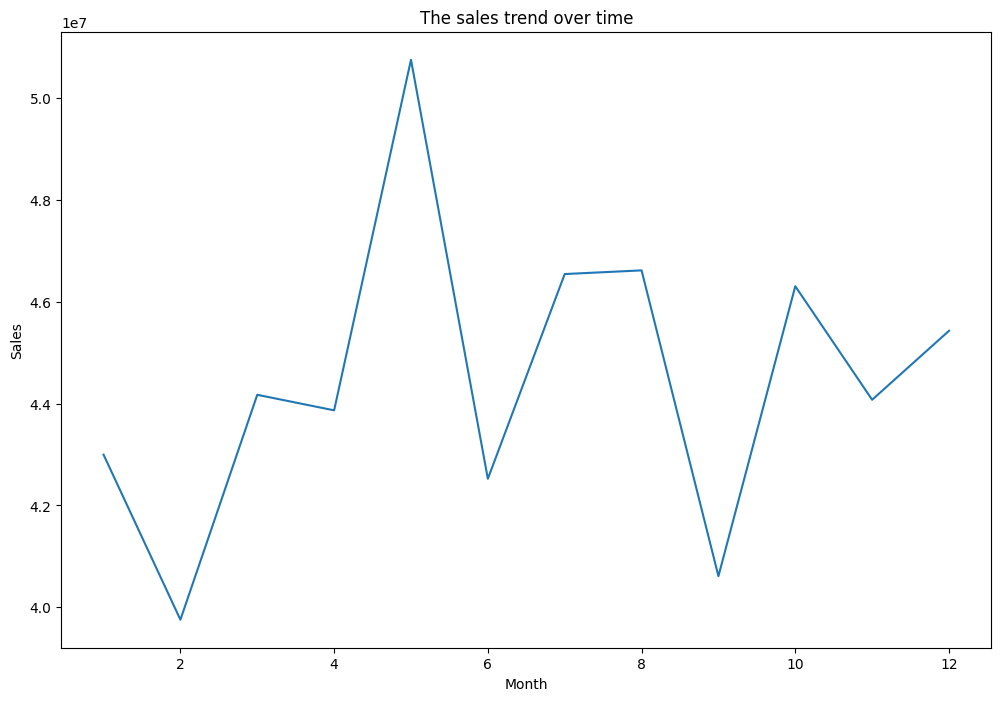

In [19]:
trend= df.groupby('Month')['Sales'].sum()
trend.plot(x='Month', y='Sales', kind='line', figsize=(12,8))
plt.title('The sales trend over time')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout
plt.show()

From the plot, we can see the time of the year where the sales are the highest . This can help the business make informed decisions to 
maximize profits and minimize loss. E.g High restocking in June and February may make the business incur more loss as we have low sales and perishable 
goods may expire. The business is likely to make high profits when the restock accordingly around the month of  January, March, May, July, August, October and December

# Checking sales trend of categories over time in different Regions

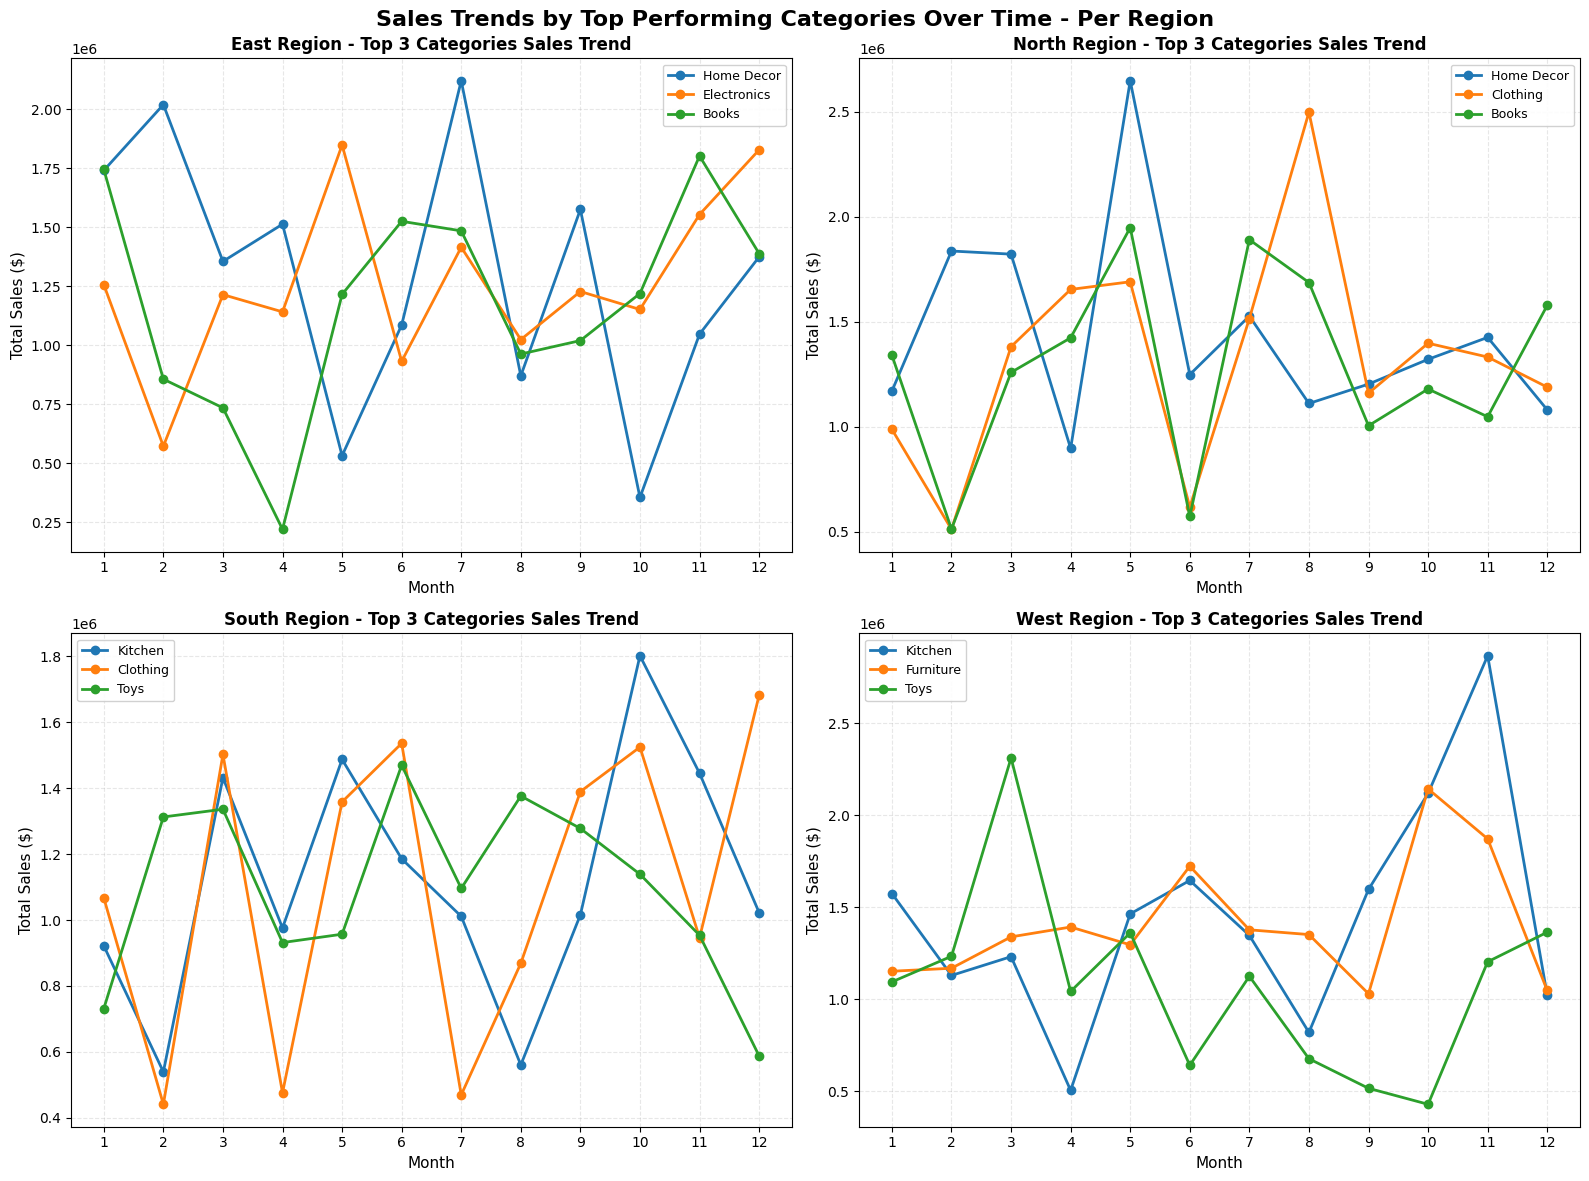

In [20]:
# Plot trend of sales per category in different times for each region
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Trends by Top Performing Categories Over Time - Per Region', fontsize=16, fontweight='bold')

# Get unique regions
regions = sorted(df['Region'].unique())

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Create a plot for each region
for idx, region in enumerate(regions):
    ax = axes_flat[idx]
    
    # Filter data for this region
    region_data = df[df['Region'] == region]
    
    # Get top 3 performing categories by total sales in this region
    top_categories = region_data.groupby('Category')['Sales'].sum().nlargest(3).index.tolist()
    
    # Plot only top categories as separate lines
    for cat in top_categories:
        cat_data = region_data[region_data['Category'] == cat].groupby('Month')['Sales'].sum()
        ax.plot(cat_data.index, cat_data.values, marker='o', label=cat, linewidth=2, markersize=6)
    
    ax.set_title(f'{region} Region - Top 3 Categories Sales Trend', fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Total Sales ($)', fontsize=11)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

From the graph we displayed the trend of sales of the most selling categories on different regions throughout the year to identify
some of the categories that could be in peak demand in a specific month of the year. we realize that  in the east region, electronics sell
the highest during the month of may, home decor in July and Books in November. In the north region, Home Decor sell the highest during may, Clothing 
during August and Books during December.On the other hand in the South Region,kitchen category goods sell the most during October, Toys during August and Clothing
during December. Finally in the West region, Toys in March are the highest selling category, Furniture during june and Kitchen during November.
This helps the business make informed decision in restocking goods in different regions.

# Data Splitting and Preparations

Linear Regression model

In [21]:
#Regression model to predict sales 
# Prepare the data for modelling with One-Hot Encoding
x_encode = pd.get_dummies(df[['City', 'Region', 'Category', 'Sub-Category', 'Payment Mode']], drop_first=True)
# Combine encoded features with Discount, Quantity, and Unit Price
X = pd.concat([x_encode, df[['Discount', 'Unit Price', 'Quantity']]], axis=1)
y = df['Sales']
y_scaler=StandardScaler()
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




We are building a model that forecasts the sales based on city, Region, Sub-Category, Payment Mode, Discount, Unit Price and Quantity.
we are splitting the data into training and splitting test. we are using 80% to train the model and 20% to test the model. the non numerical
features are encoded to categorical values.

# Modelling

In [22]:

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
train_r2 = model.score(X_train, y_train)

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared (Test): {r2:.4f}')
print(f'R-squared (Train): {train_r2:.4f}')


Root Mean Squared Error: 30761.46
R-squared (Test): 0.8755
R-squared (Train): 0.8781


The model accounts for 87.81% change in sales. This model makes an error of approximately + or - 30761.46
Let us check the importance of each feature in our model 

# Evaluation

In [23]:
# Feature importance grouped by main feature categories
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': abs(model.coef_)
})

# Extract base feature names for grouping
def get_base_feature(feature_name):
    if '_' in feature_name:
        return feature_name.split('_')[0]
    else:
        return feature_name

coefficients['Base_Feature'] = coefficients['Feature'].apply(get_base_feature)

# Group by base feature and sum the absolute coefficients
grouped_importance = coefficients.groupby('Base_Feature').agg({
    'Abs_Coefficient': 'sum',
    'Coefficient': 'sum'
}).reset_index()

# Rename columns for clarity
grouped_importance.columns = ['Feature_Group', 'Total_Abs_Importance', 'Total_Coefficient']
grouped_importance = grouped_importance.sort_values('Total_Abs_Importance', ascending=False)

print("\n FEATURE IMPORTANCE BY CATEGORY ")
print("(Importance measured by sum of absolute coefficients)")
print(grouped_importance.to_string(index=False))




 FEATURE IMPORTANCE BY CATEGORY 
(Importance measured by sum of absolute coefficients)
Feature_Group  Total_Abs_Importance  Total_Coefficient
 Sub-Category         107649.266509      -16447.711186
     Quantity          35982.072385       35982.072385
         City          28773.454823        1067.013567
     Category          12714.511809        7602.733066
 Payment Mode           2314.679691       -2314.679691
       Region           1797.580710        1035.291717
     Discount           1133.695541       -1133.695541
   Unit Price              2.676230           2.676230


In [24]:
# Print summary statistics
print("\n SUMMARY")
total_importance = grouped_importance['Total_Abs_Importance'].sum()
for idx, row in grouped_importance.iterrows():
    percentage = (row['Total_Abs_Importance'] / total_importance) * 100
    print(f"{row['Feature_Group']}: {row['Total_Abs_Importance']:.2f} ({percentage:.1f}%)")



 SUMMARY
Sub-Category: 107649.27 (56.5%)
Quantity: 35982.07 (18.9%)
City: 28773.45 (15.1%)
Category: 12714.51 (6.7%)
Payment Mode: 2314.68 (1.2%)
Region: 1797.58 (0.9%)
Discount: 1133.70 (0.6%)
Unit Price: 2.68 (0.0%)


In [25]:
# Try Random Forest for comparison

# Create and fit the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)
train_r2_rf = rf_model.score(X_train, y_train)

print("\n RANDOM FOREST MODEL ")
print(f'Root Mean Squared Error: {rmse_rf:.2f}')
print(f'R-squared (Test): {r2_rf:.4f}')
print(f'R-squared (Train): {train_r2_rf:.4f}')


 RANDOM FOREST MODEL 
Root Mean Squared Error: 2108.64
R-squared (Test): 0.9994
R-squared (Train): 0.9999


From the above models we can see that Random Forest gives us a higher r2_score. That shows that random forest model accounts for more variability
in sales. Random forest predicts sales better. 

Cross Validation

In [26]:
# Linear Regression model Cross validation
lr = LinearRegression()

scores_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')

print("LR scores:", scores_lr)
print("LR mean:", scores_lr.mean())

LR scores: [0.87440919 0.88180752 0.87078672 0.8648173  0.87871558]
LR mean: 0.8741072644482074


In [27]:
# Random Forest model Cross validation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("RF scores:", scores_rf)
print("RF mean:", scores_rf.mean())

RF scores: [0.99936828 0.9993606  0.99948242 0.99937453 0.99942368]
RF mean: 0.9994019016177212


I compared my linear regression model with the random forest model. At first it appears the random forest model predicts sales
perfectly and outperforms Linear Regression model but further analysis revealed signs of overfitting and sensitivity to feature leakage
Therefore, LinearRegression model was selected as the final model due to it's better generalization and stability.

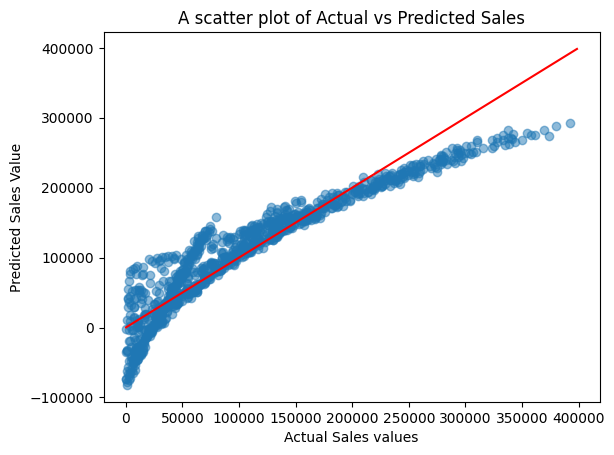

In [28]:
# Plot a scatter plot of predicted vs actual values of LR model
plt.scatter(y_test,y_pred, alpha=0.5)
plt.plot([y.min(),y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Sales values')
plt.ylabel('Predicted Sales Value')
plt. title('A scatter plot of Actual vs Predicted Sales')
plt.show()


In [29]:
# Negative Sales Prediction
print(y_pred.min())
negative_sales=(y_pred<0).sum()
print(negative_sales)
print((y_pred<0).mean()*100)

-82097.48240580218
100
10.0


The graph shows that predictions follow the trend of actual sales. However, the points form an r shaped pattern instead of aligning closely with the prediction line. This shows that the model does not fully capture the non-linear relationships within the data. Additionaly, we have 10% of negative sales prediction which is unrealistic for sales. This poses as a limitation for using Linear Regression for this dataset. Let's check for the same in Random Forest Model 


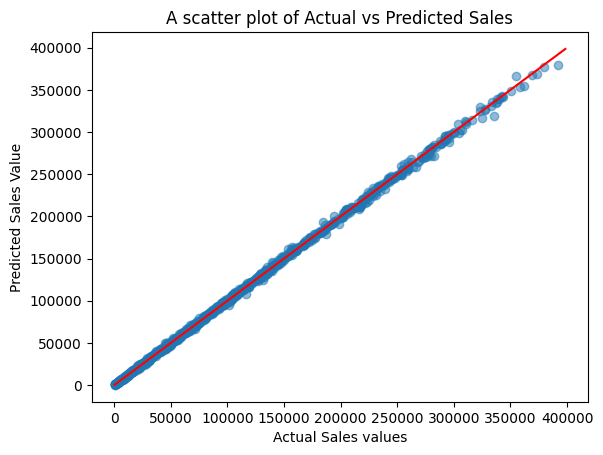

In [30]:
# Plot a scatter plot of predicted vs actual values of random forest model 
plt.scatter(y_test,y_pred_rf, alpha=0.5)
plt.plot([y.min(),y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Sales values')
plt.ylabel('Predicted Sales Value')
plt. title('A scatter plot of Actual vs Predicted Sales')
plt.show()

From the plot we realize that random forest model shows that the predicted sales closely follow the actual sales values than the Linear Regression model. Additionaly, there are no negative predicted sales. This indicates that this model captures the relationship between predictor variables and sales more accurately leading to improved prediction performance.

# Models performance comparison
Both models were evaluated to deteremine the most suitable model for sales forecasting. The random forest model achieved 
a higher R-squared value and lower RMSE compared to the linear regression model, indicating better predictive performance.
The Random Forest model explained more of the variance in sales and is less prone to overfitting, making it a better  choice for this dataset.


# Final Model Selection
Two machine learning models, Linear Regression and Random Forest Regression, were developed and evaluated for sales forecasting. Model selection was based not only on predictive accuracy but also on diagnostic analysis. Although Linear Regression achieved good predictive performance, its residual plot exhibited a U-shaped pattern, indicating that some non-linear relationships in the data were not fully captured. In contrast, the Random Forest model produced residuals that were randomly scattered around zero with no discernible pattern, suggesting that it captured the underlying relationships more effectively. The Random Forest model also demonstrated competitive predictive performance while maintaining good generalization. Therefore, it was selected as the final model for this project.


 RESIDUAL ANALYSIS 


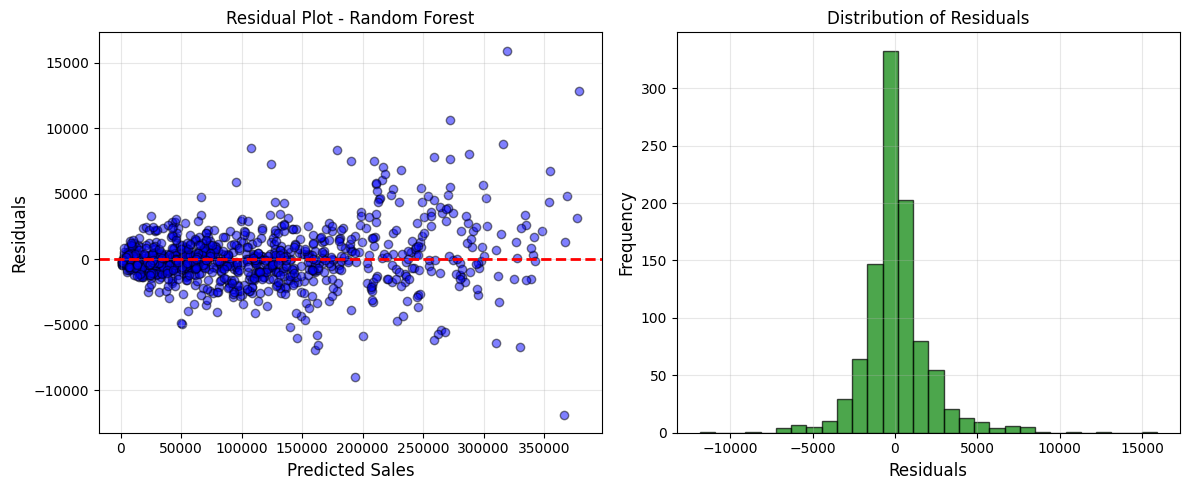

Mean of Residuals: 65.6665
Std Dev of Residuals: 2108.6744
Min Residual: -11867.5999
Max Residual: 15925.5393


In [31]:
# Residual Plot 
print("\n RESIDUAL ANALYSIS ")
residuals = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted Values
plt.subplot(1, 2, 1)
plt.scatter(y_pred_rf, residuals, alpha=0.5, color='blue', edgecolors='black')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot - Random Forest', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")


Residual analysis was performed to evaluate the quality of the Random Forest model. The residual plot, which displays residuals against predicted sales values, showed that the residuals were randomly scattered around zero with no visible pattern. This indicates that the model successfully captured the underlying relationships in the data and that there were no systematic prediction errors.

In addition, the histogram of the residuals exhibited an approximately bell-shaped distribution centered around zero. This suggests that the prediction errors are balanced, with most errors being small and only a few large deviations. Together, these diagnostic results indicate that the Random Forest model provides reliable and unbiased predictions for the sales forecasting task.

# CONCLUSION
This project successfully developed a machine learning solution for forecasting e-commerce sales to support inventory and supply chain decision-making. Through exploratory data analysis, several factors influencing sales were identified, including product category, region, city, payment mode, unit price, quantity, and seasonal trends. These insights revealed periods of high demand across different regions and product categories, enabling the business to better understand customer purchasing patterns.

Two predictive models, Linear Regression and Random Forest Regression, were developed and evaluated using multiple performance metrics and diagnostic analyses. Although both models demonstrated good predictive capability, Random Forest Regression was selected as the final model because it achieved superior predictive performance and produced well-behaved residuals without systematic patterns, indicating a better fit for the data.

The resulting sales forecasting model provides the business with a practical tool for anticipating future demand, improving inventory planning, minimizing stockouts, optimizing restocking decisions, and supporting data-driven marketing and operational strategies. Overall, the project demonstrates how machine learning can transform historical sales data into actionable business insights that improve decision-making and operational efficiency.

In [32]:
# Predict on new data
print("\n PREDICTION ON NEW DATA ")
# Create a sample prediction
new_sample = pd.DataFrame({
    'City_Chicago': [0], 'City_Houston': [0], 'City_Los Angeles': [1], 'City_Miami': [0], 'City_New York': [0],
    'Region_East': [0], 'Region_Midwest': [0], 'Region_South': [0], 'Region_West': [1],
    'Category_Clothing': [0], 'Category_Electronics': [0], 'Category_Furniture': [0], 'Category_Groceries': [0],
    'Category_Home Decor': [1], 'Category_Kitchen': [0], 'Category_Sports': [0], 'Category_Toys': [0],
    'Sub-Category_Accessories': [0], 'Sub-Category_Appliances': [0], 'Sub-Category_Beauty': [0],
    'Sub-Category_Books': [0], 'Sub-Category_Clothing': [1], 'Sub-Category_Furniture': [0],
    'Sub-Category_Gaming': [0], 'Sub-Category_Home Decor': [0], 'Sub-Category_Kitchen': [0],
    'Sub-Category_Phones': [0], 'Sub-Category_Shoes': [0], 'Sub-Category_Sports': [0], 'Sub-Category_Toys': [0],
    'Payment Mode_Card': [0], 'Payment Mode_Cash': [0], 'Payment Mode_Cheque': [0], 'Payment Mode_COD': [1], 'Payment Mode_Online': [0],
    'Discount': [0.15], 'Quantity': [5], 'Unit Price': [50]
})

# Ensure columns match X_train
new_sample = new_sample.reindex(columns=X_train.columns, fill_value=0)
predicted_sales = rf_model.predict(new_sample)
print(f"Predicted Sales for new sample: {predicted_sales[0]:.2f}")



 PREDICTION ON NEW DATA 
Predicted Sales for new sample: 1419.41
